<a href="https://colab.research.google.com/github/mqquiroz/ICV513/blob/main/Analisis_Espectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis Espectral

Creamos dos funciones que describen la superficie libre:

$$\eta(t) = \eta_{1} + \eta_{2} = a_{1}\sin(\omega_{1} t) + a_{2}\sin(\omega_{2} t) $$

In [68]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import math
import requests
from io import StringIO

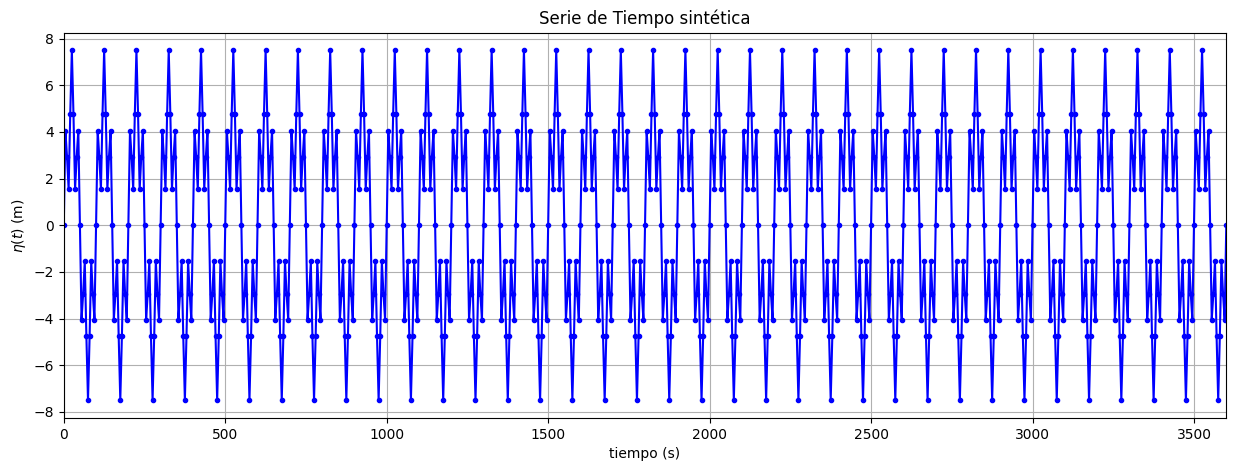

In [65]:
# Generar una serie de tiempo sintética
#Datos
#Frecuencias lineales
f1 = 0.01 #[Hz]
f2 = 0.05 #[Hz]

#Frecuencias angulares
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2
#Amplitud
a1 = 5   #(m)
a2 = 2.5 #(m)

#paso de tiempo
dt = 5 #(s)
t_total = 60*60 # 1 hora = 3600 s

#vector del tiempo
t = np.arange(0,t_total+dt,dt)

#eta
eta = a1*np.sin(w1*t) + a2*np.sin(w2*t)

alto = 5
ancho = 15
plt.figure(1,figsize=(ancho,alto))

plt.plot(t,eta,'.-b')
plt.xlim(t[0],t[-1])
plt.xlabel('tiempo (s)')
plt.ylabel('$\eta(t)$ (m)')
plt.title('Serie de Tiempo sintética')
plt.grid()
plt.show()

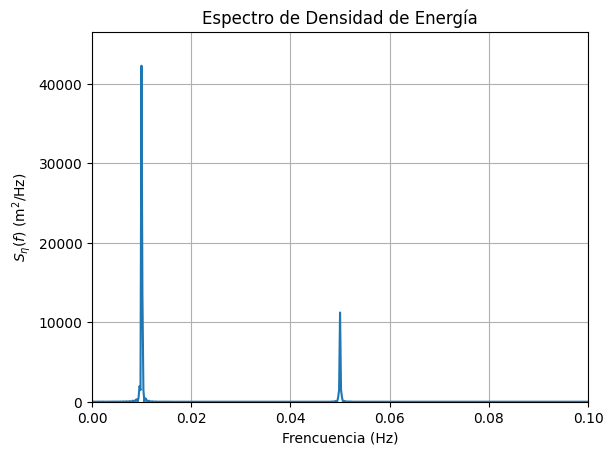

In [66]:
N    = len(eta) # cantidad de datos del registro
fs   = 1/dt     # frecuencia de Muestreo (Hz)
T0   = t_total  # longitud en tiempo del registro (s)
df   = 1/T0     # delta f (resolución espectral)
fmin = df       # Frecuencia mínima del espectro
fmax = fs/2     # Frecuencia máxima del espectro (Fnyquist)

def nextpow2(x):
  valor = math.ceil(np.log2(abs(x)))
  return valor

NFFT = 2**nextpow2(N)

Coefs = np.fft.fft(eta,NFFT)
amp   = (2/N)*np.abs(Coefs[0:int(NFFT/2+1)] )
Sf    = (1/2)*(amp**2)/df

f = (fs/2)*np.linspace(0,1,int(NFFT/2+1))

plt.plot(f,Sf)
plt.xlim(0,f[-1])
plt.ylim(0,1.1*np.max(Sf))
plt.xlabel('Frencuencia (Hz)')
plt.ylabel('$S_{\eta}(f)$ (m$^{2}$/Hz)')
plt.title('Espectro de Densidad de Energía')
plt.grid()
plt.show()

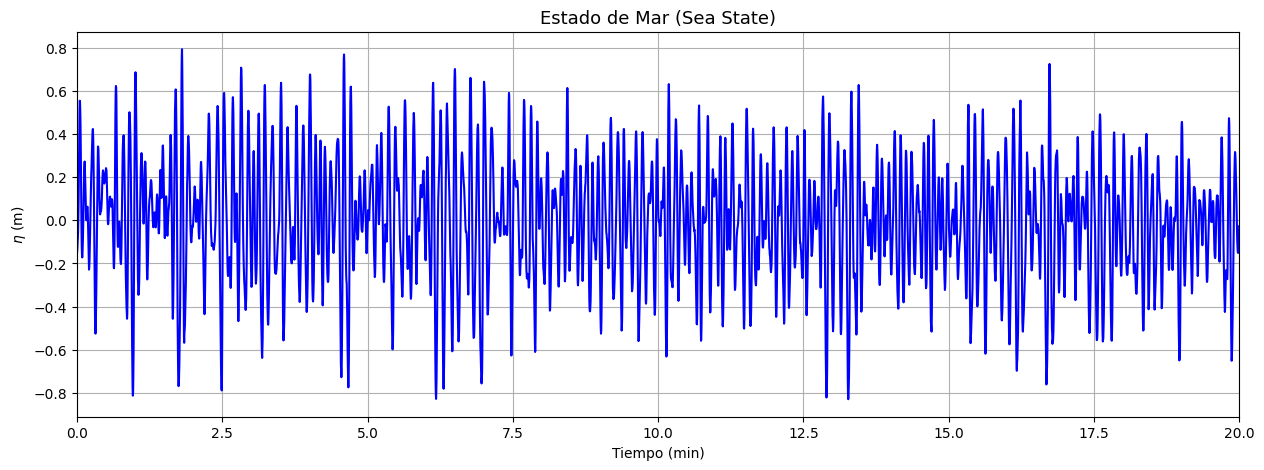

In [72]:
#Cargar serie de tiempo (datos) de Estado de Mar (desde GitHub)
url = 'https://raw.githubusercontent.com/mqquiroz/ICV513/refs/heads/main/F3-4.dat'
data = requests.get(url)
data = data.text
data = StringIO(data)
#print(data)
data   = np.loadtxt(data,skiprows=3)

#Cargar serie de tiempo (datos) desde carpeta de Google Colab (Otra opción)
#data   = np.loadtxt('F3-4.dat',skiprows=3)

tiempo = data[:,0]/60 #Primera columna tiempos (min)
eta    = data[:,1] #Segunda columna eta (m)


eta_mean = np.mean(eta) # eta promedio (m)
eta      = eta - eta_mean # a eta le restamos la media

#Declaramos figura (fig) y eje (ax)
fig, ax = plt.subplots(figsize=(ancho,alto))

ax.plot(tiempo,eta,'b')
#plt.axhline(y=np.mean(eta),color='r')
ax.set_xlim([0,20])
ax.set_xlabel('Tiempo (min)',fontsize=10)
ax.set_ylabel('$\eta$ (m)',fontsize=10)
ax.set_title('Estado de Mar (Sea State)',fontsize=10+3)
ax.grid()
plt.show()

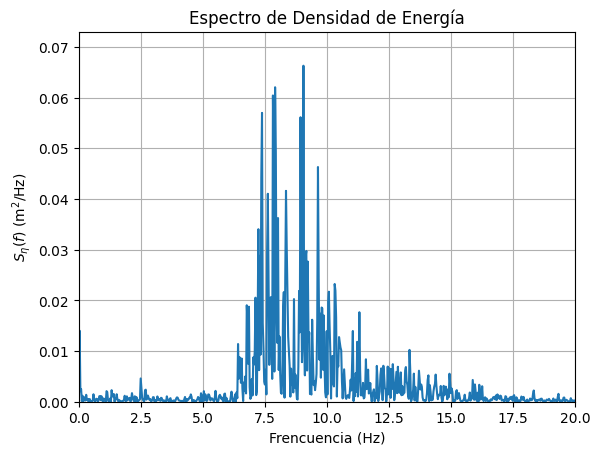

In [75]:
dt = tiempo[1]-tiempo[0]


N    = len(eta) # cantidad de datos del registro
fs   = 1/dt     # frecuencia de Muestreo (Hz)
T0   = tiempo[-1]  # longitud en tiempo del registro (s)
df   = 1/T0     # delta f (resolución espectral)
fmin = df       # Frecuencia mínima del espectro
fmax = fs/2     # Frecuencia máxima del espectro (Fnyquist)

def nextpow2(x):
  valor = math.ceil(np.log2(abs(x)))
  return valor

NFFT = 2**nextpow2(N)

Coefs = np.fft.fft(eta,NFFT)
amp   = (2/N)*np.abs(Coefs[0:int(NFFT/2+1)] )
Sf    = (1/2)*(amp**2)/df

f = (fs/2)*np.linspace(0,1,int(NFFT/2+1))

plt.plot(f,Sf)
plt.xlim(0,20)
plt.ylim(0,1.1*np.max(Sf))
plt.xlabel('Frencuencia (Hz)')
plt.ylabel('$S_{\eta}(f)$ (m$^{2}$/Hz)')
plt.title('Espectro de Densidad de Energía')
plt.grid()
plt.show()